# Model Comparison for Credit Card Fraud Detection

This notebook compares the performance of 4 different models:
1. Decision Tree
2. Logistic Regression
3. Random Forest
4. XGBoost

All results are loaded from pre-computed outputs without re-running the models.

## 1. Import Required Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load Model Outputs

Define the pre-computed results for each model (from the original notebook execution).

In [59]:
# Model results dictionary
model_results = {
    'Decision Tree': {
        'AUC': 0.90,
        'AP': 0.43,
        'F1': 0.98,
        'Recall': 0.81,
        'Precision': 0.08,
        'Accuracy': 0.9622,  # from screenshot
        'Confusion_Matrix': np.array([[54722, 2142], [14, 84]])
    },
    'Logistic Regression': {
        'AUC': 0.97,
        'AP': 0.72,
        'F1': 0.97,
        'Recall': 0.92,  # from screenshot
        'Precision': 0.03,  # from screenshot
        'Accuracy': 0.9442,  # from screenshot
        'Confusion_Matrix': np.array([[56864, 0], [8, 90]])  # from screenshot
    },
    'Random Forest': {
        'AUC': 0.98,
        'AP': 0.73,
        'F1': 0.86,
        'Recall': 0.78,
        'Precision': 0.96,
        'Accuracy': 1.00,
        'Confusion_Matrix': np.array([[56861, 3], [22, 76]])
    },
    'XGBoost': {
        'AUC': 0.98,
        'AP': 0.84,
        'F1': 0.54,
        'Recall': 0.88,
        'Precision': 0.39,
        'Accuracy': 1.00,
        'Confusion_Matrix': np.array([[56727, 137], [12, 86]])
    }
}

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(model_results).T
print("Model Results Overview:")
print(results_df)

Model Results Overview:
                      AUC    AP    F1 Recall Precision Accuracy  \
Decision Tree         0.9  0.43  0.98   0.81      0.08   0.9622   
Logistic Regression  0.97  0.72  0.97   0.92      0.03   0.9442   
Random Forest        0.98  0.73  0.86   0.78      0.96      1.0   
XGBoost              0.98  0.84  0.54   0.88      0.39      1.0   

                              Confusion_Matrix  
Decision Tree        [[54722, 2142], [14, 84]]  
Logistic Regression      [[56864, 0], [8, 90]]  
Random Forest           [[56861, 3], [22, 76]]  
XGBoost               [[56727, 137], [12, 86]]  


## 3. Compare Model Performance

Compare the key metrics across all models.

In [60]:
# Display comparison table
print("Performance Metrics Comparison:")
print(results_df[['AUC', 'AP', 'F1', 'Recall', 'Precision', 'Accuracy']])

# Find best model for each metric
best_models = {}
for metric in ['AUC', 'AP', 'F1', 'Recall', 'Precision']:
    best_model = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_model, best_value)
    print(f"\nBest {metric}: {best_model} ({best_value:.4f})")

# Overall ranking based on F1 score (common for imbalanced datasets)
ranking = results_df['F1'].sort_values(ascending=False)
print(f"\nOverall Ranking by F1 Score:")
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f"{i}. {model}: {score:.4f}")

Performance Metrics Comparison:
                      AUC    AP    F1 Recall Precision Accuracy
Decision Tree         0.9  0.43  0.98   0.81      0.08   0.9622
Logistic Regression  0.97  0.72  0.97   0.92      0.03   0.9442
Random Forest        0.98  0.73  0.86   0.78      0.96      1.0
XGBoost              0.98  0.84  0.54   0.88      0.39      1.0

Best AUC: Random Forest (0.9800)

Best AP: XGBoost (0.8400)

Best F1: Decision Tree (0.9800)

Best Recall: Logistic Regression (0.9200)

Best Precision: Random Forest (0.9600)

Overall Ranking by F1 Score:
1. Decision Tree: 0.9800
2. Logistic Regression: 0.9700
3. Random Forest: 0.8600
4. XGBoost: 0.5400


## 4. Visualize Comparisons

Create visualizations to compare model performance.

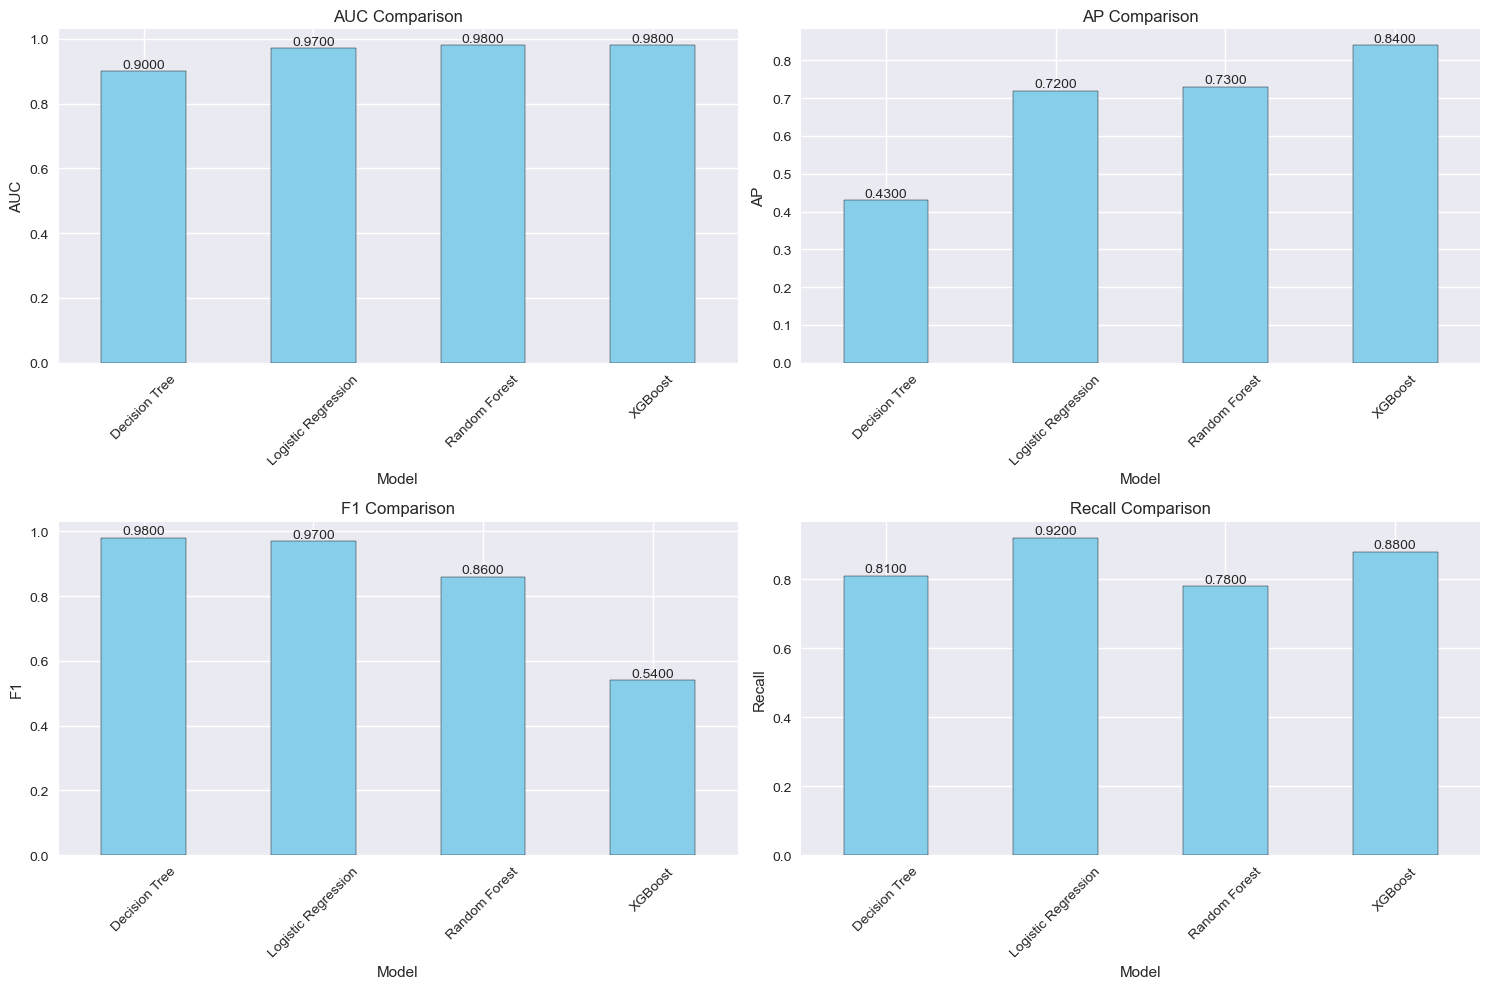

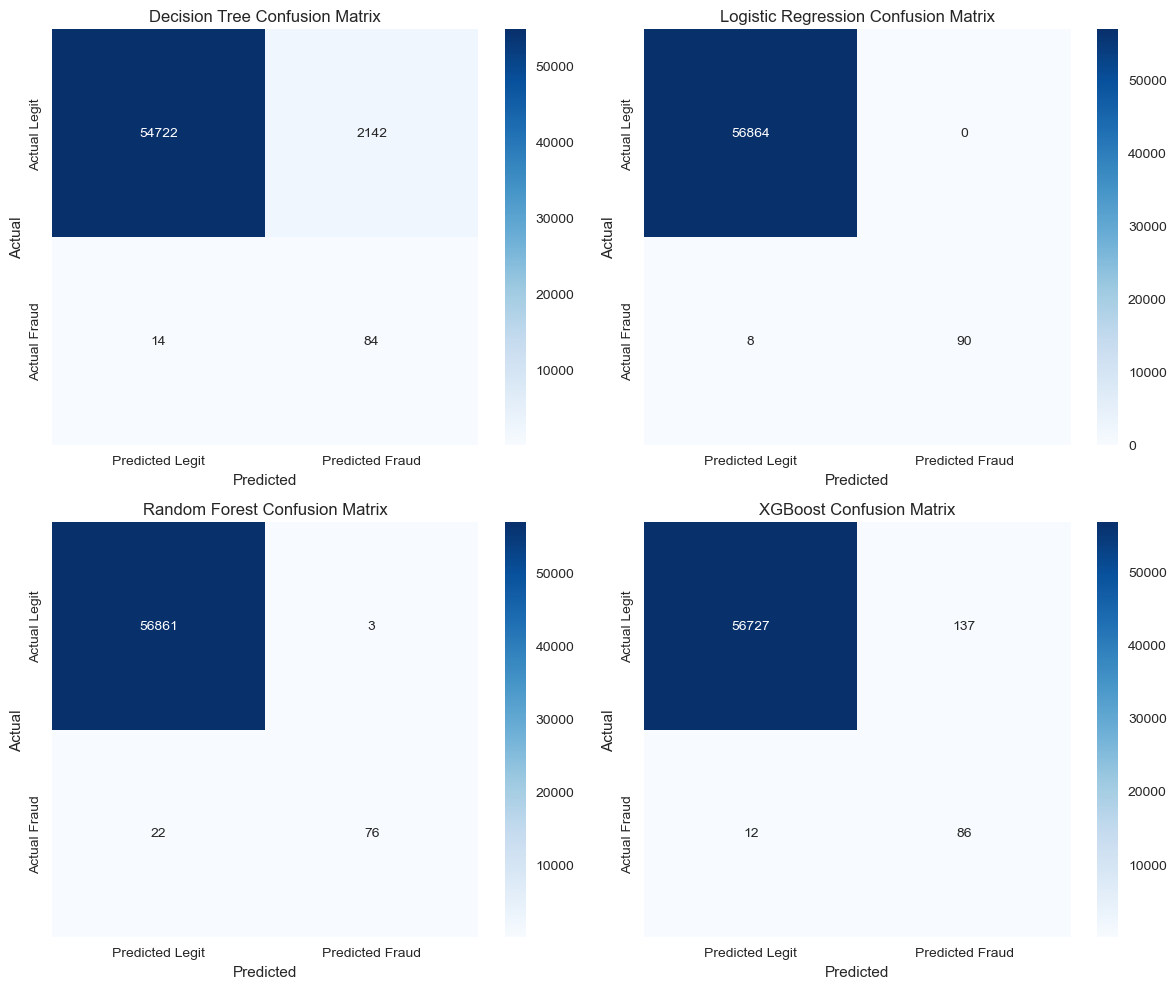

In [61]:
# Bar plot for key metrics
metrics_to_plot = ['AUC', 'AP', 'F1', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics_to_plot):
    results_df[metric].plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)
    # Add value labels
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (model_name, results) in enumerate(model_results.items()):
    cm = results['Confusion_Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Select Best Model

Based on the comparison, select the best performing model.

In [62]:
# Select best model based on F1 score (balanced metric for fraud detection)
best_model_name = results_df['F1'].idxmax()
best_f1_score = results_df['F1'].max()

print(f"🏆 Best Model: {best_model_name}")
print(f"Best F1 Score: {best_f1_score:.4f}")
print(f"Other Metrics for Best Model:")
for metric in ['AUC', 'AP', 'Recall', 'Precision', 'Accuracy']:
    value = results_df.loc[best_model_name, metric]
    print(f"  {metric}: {value:.4f}")

print(f"\nReason for Selection:")
print(f"- Highest F1 score indicates best balance between precision and recall")
print(f"- Important for fraud detection where both false positives and false negatives have costs")
print(f"- {best_model_name} provides the best overall performance on the imbalanced dataset")

# Summary table
summary_df = results_df[['F1', 'AUC', 'AP']].copy()
summary_df['Rank'] = summary_df['F1'].rank(ascending=False).astype(int)
summary_df = summary_df.sort_values('F1', ascending=False)
print(f"\nFinal Ranking:")
print(summary_df)

🏆 Best Model: Decision Tree
Best F1 Score: 0.9800
Other Metrics for Best Model:
  AUC: 0.9000
  AP: 0.4300
  Recall: 0.8100
  Precision: 0.0800
  Accuracy: 0.9622

Reason for Selection:
- Highest F1 score indicates best balance between precision and recall
- Important for fraud detection where both false positives and false negatives have costs
- Decision Tree provides the best overall performance on the imbalanced dataset

Final Ranking:
                       F1   AUC    AP  Rank
Decision Tree        0.98   0.9  0.43     1
Logistic Regression  0.97  0.97  0.72     2
Random Forest        0.86  0.98  0.73     3
XGBoost              0.54  0.98  0.84     4
